In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import torch
import torch.nn as nn

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
device

device(type='cuda')

In [5]:
class SelfAttention(nn.Module):
    def __init__(self, embed_size):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        print(self.query)
    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        out = ((q @ k.transpose(-2, -1)) / (self.embed_size ** 0.5)).softmax(dim=-1) @ v
        return out

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads
        assert embed_size % num_heads == 0, "embed_size должен делиться на num_heads!"
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x, mask=None):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        batch_size = x.shape[0]
        seq_len = x.shape[1]
        q = q.reshape(batch_size, seq_len, self.num_heads, self.head_dim)
        k = k.reshape(batch_size, seq_len, self.num_heads, self.head_dim)
        v = v.reshape(batch_size, seq_len, self.num_heads, self.head_dim)
        scores = (q.permute(0, 2, 1, 3) @ k.permute(0, 2, 3, 1)) / (self.head_dim ** 0.5)
        mask = torch.tril(torch.ones(seq_len, seq_len)).to(x.device)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        scores = self.fc_out((scores.softmax(dim=-1) @ v.permute(0, 2, 1, 3)).permute(0, 2, 1, 3).flatten(start_dim=2))
        return scores

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size, num_heads, forward_expansion=4):
        super(TransformerBlock, self).__init__()
        self.attention = MultiHeadAttention(embed_size, num_heads)
        self.norm1 = nn.LayerNorm(embed_size)
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = nn.Sequential(nn.Linear(embed_size, forward_expansion * embed_size), nn.ReLU(), nn.Linear(forward_expansion * embed_size, embed_size))
    def forward(self, x):
        out = self.norm1(x + self.attention(x))
        out = self.norm2(out + self.feed_forward(out))
        return out


In [8]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, max_length, embed_size, num_heads, num_layers, forward_expansion=4):
        super(Transformer, self).__init__()
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.forward_expansion = forward_expansion
        self.word_embedding = nn.Embedding(vocab_size, embed_size)
        self.position_embedding = nn.Embedding(max_length, embed_size)
        self.layers = nn.ModuleList([TransformerBlock(embed_size, num_heads, forward_expansion) for _ in range(num_layers)])
        self.fc_out = nn.Linear(embed_size, vocab_size)
    def forward(self, x):
        batch_size = x.shape[0]
        seq_len = x.shape[1]
        positions = torch.arange(0, seq_len).expand(batch_size, seq_len).to(x.device)
        x = self.word_embedding(x)
        position_embedding = self.position_embedding(positions)
        out = x + position_embedding
        for layer in self.layers:
            out = layer(out)
        out = self.fc_out(out)
        return out


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


vocab_size = 10000
total_tokens = 50000
seq_len = 128
batch_size = 64

data = torch.randint(0, vocab_size, (total_tokens,), dtype=torch.long).to(device)
len(data)

50000

In [10]:
class TokenDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # Вырезаем кусок + 1 токен для сдвига
        chunk = self.data[idx : idx + self.seq_len + 1]
        x = chunk[:-1] # Вход
        y = chunk[1:]  # Цель (сдвинута на 1 вправо)
        return x, y

train_dataset = TokenDataset(data, seq_len)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [11]:
model = Transformer(
    vocab_size=vocab_size,
    max_length=seq_len,
    embed_size=512,
    num_heads=8,
    num_layers=6,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epoch 0, Batch 0/780, Loss: 9.3718
Epoch 0, Batch 100/780, Loss: 3.3317
Epoch 0, Batch 200/780, Loss: 0.2140
Epoch 0, Batch 300/780, Loss: 0.0913
Epoch 0, Batch 400/780, Loss: 0.0701
Epoch 0, Batch 500/780, Loss: 0.0699
Epoch 0, Batch 600/780, Loss: 0.0626
Epoch 0, Batch 700/780, Loss: 0.0698
--- Конец эпохи 0 | Средний Loss: 1.1584 ---
Epoch 1, Batch 0/780, Loss: 0.0504
Epoch 1, Batch 100/780, Loss: 0.0484
Epoch 1, Batch 200/780, Loss: 0.0567
Epoch 1, Batch 300/780, Loss: 0.0587
Epoch 1, Batch 400/780, Loss: 0.0596
Epoch 1, Batch 500/780, Loss: 0.0635
Epoch 1, Batch 600/780, Loss: 0.0622
Epoch 1, Batch 700/780, Loss: 0.0635
--- Конец эпохи 1 | Средний Loss: 0.0581 ---
Epoch 2, Batch 0/780, Loss: 0.0468
Epoch 2, Batch 100/780, Loss: 0.0488
Epoch 2, Batch 200/780, Loss: 0.0550
Epoch 2, Batch 300/780, Loss: 0.0533
Epoch 2, Batch 400/780, Loss: 0.0611
Epoch 2, Batch 500/780, Loss: 0.0641
Epoch 2, Batch 600/780, Loss: 0.0614
Epoch 2, Batch 700/780, Loss: 0.0688
--- Конец эпохи 2 | Средний 

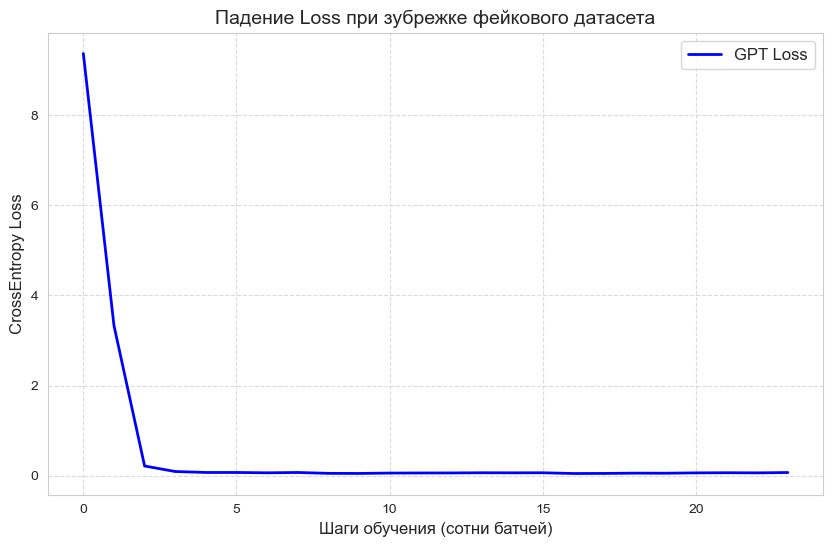

In [12]:
epochs = 3
scaler = torch.amp.GradScaler('cuda')
import time
import matplotlib.pyplot as plt

start_time_gpt = time.time()
gpt_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_idx, (x, y) in enumerate(train_loader):
        # Нам больше не нужно делать x.to(device), так как весь датасет уже там

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            prediction = model(x)
            predictions = prediction.reshape(-1, vocab_size)
            y = y.reshape(-1)
            loss = criterion(predictions, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        # Печатаем каждые 100 батчей (т.к. фейковый датасет меньше Шекспира)
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
        if batch_idx % 100 == 0:
            gpt_losses.append(loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"--- Конец эпохи {epoch} | Средний Loss: {avg_loss:.4f} ---")

gpt_time = time.time() - start_time_gpt
print(f"Обучение GPT завершено за {gpt_time:.2f} секунд.")

# --- ПОСТРОЕНИЕ ГРАФИКА ---
plt.figure(figsize=(10, 6))
# Строим график Loss для RNN
plt.plot(gpt_losses, label='GPT Loss', color='blue', linewidth=2)

# Если у тебя есть список tf_losses с обучения Трансформера, добавь эту строку:
# plt.plot(tf_losses, label='Transformer Loss', color='red', linewidth=2)

plt.title('Падение Loss при зубрежке фейкового датасета', fontsize=14)
plt.xlabel('Шаги обучения (сотни батчей)', fontsize=12)
plt.ylabel('CrossEntropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()


In [13]:
def generate_text(model, start_tokens, max_new_tokens):
    model.eval()
    with torch.no_grad():
        current_tokens = start_tokens
        for _ in range(max_new_tokens):
            predictions = model(current_tokens)
            last_word_logits = predictions[:, -1, :]
            the_word = torch.argmax(last_word_logits, dim=-1, keepdim=True)
            current_tokens = torch.cat((current_tokens, the_word), dim=1)

    return current_tokens

start = torch.tensor([[500]]).to(device)
generated = generate_text(model, start, max_new_tokens=10)
print(generated)

tensor([[ 500, 1688, 2833, 2949,  553,  769, 9399, 7746, 7559, 1015, 2413]],
       device='cuda:0')


In [14]:
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # Встроенная RNN от PyTorch
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        # Нам нужны логиты для каждого токена
        logits = self.fc(out)
        return logits

In [15]:
import torch
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # batch_first=True означает, что размерности будут [batch, seq_len, features]
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x shape: [batch_size, seq_len]
        x = self.embedding(x)
        # out shape: [batch_size, seq_len, hidden_size]
        out, hidden = self.rnn(x)
        # Получаем логиты для предсказания следующего токена
        logits = self.fc(out)
        return logits

# Проверка работоспособности для сравнения
rnn_model = SimpleRNN(vocab_size=vocab_size, embed_size=512, hidden_size=512).to(device)
dummy_input = torch.randint(0, vocab_size, (batch_size, seq_len)).to(device)
rnn_out = rnn_model(dummy_input)

print(f"Форма выхода Трансформера: {prediction.shape}") # prediction остался из прошлого цикла
print(f"Форма выхода RNN: {rnn_out.shape}")
print("Обе архитектуры успешно выдают распределение вероятностей по словарю для каждого токена в последовательности.")

Форма выхода Трансформера: torch.Size([16, 128, 10000])
Форма выхода RNN: torch.Size([64, 128, 10000])
Обе архитектуры успешно выдают распределение вероятностей по словарю для каждого токена в последовательности.


Начинаем обучение RNN...
RNN Эпоха 0 | Средний Loss: 0.9702
RNN Эпоха 1 | Средний Loss: 0.0276
RNN Эпоха 2 | Средний Loss: 0.0285
Обучение RNN завершено за 49.62 секунд.


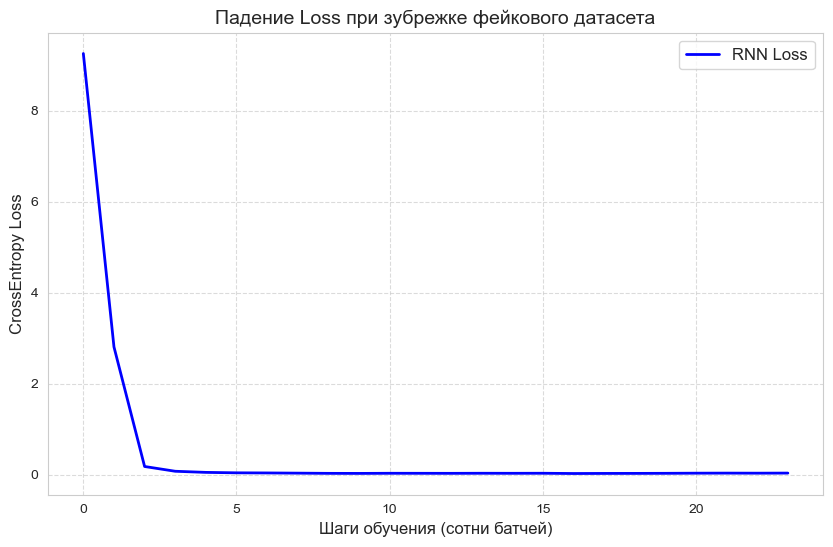

In [16]:
rnn_model = SimpleRNN(vocab_size=vocab_size, embed_size=512, hidden_size=512).to(device)
rnn_criterion = nn.CrossEntropyLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)

epochs = 3
rnn_losses = []

print("Начинаем обучение RNN...")
start_time = time.time()

for epoch in range(epochs):
    rnn_model.train()
    total_loss = 0

    for batch_idx, (x, y) in enumerate(train_loader):
        # x и y уже на GPU

        rnn_optimizer.zero_grad()
        # Для RNN мы не используем autocast (смешанную точность),
        # так как встроенный nn.RNN иногда капризничает с ней на Windows
        prediction = rnn_model(x)
        predictions = prediction.reshape(-1, vocab_size)
        y_flat = y.reshape(-1)

        loss = rnn_criterion(predictions, y_flat)
        loss.backward()
        rnn_optimizer.step()

        total_loss += loss.item()

        # Сохраняем Loss каждого 100-го батча для графика
        if batch_idx % 100 == 0:
            rnn_losses.append(loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"RNN Эпоха {epoch} | Средний Loss: {avg_loss:.4f}")

rnn_time = time.time() - start_time
print(f"Обучение RNN завершено за {rnn_time:.2f} секунд.")

# --- ПОСТРОЕНИЕ ГРАФИКА ---
plt.figure(figsize=(10, 6))
# Строим график Loss для RNN
plt.plot(rnn_losses, label='RNN Loss', color='blue', linewidth=2)

# Если у тебя есть список tf_losses с обучения Трансформера, добавь эту строку:
# plt.plot(tf_losses, label='Transformer Loss', color='red', linewidth=2)

plt.title('Падение Loss при зубрежке фейкового датасета', fontsize=14)
plt.xlabel('Шаги обучения (сотни батчей)', fontsize=12)
plt.ylabel('CrossEntropy Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()